# Canonical Correlation Analysis (CCA) for Neural Data

This notebook performs CCA to assess correlations between different brain areas during different task epochs, following a PCA-CCA pipeline with bootstrap testing and subspace comparison.

## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

# For data loading from existing pipeline
import npc_lims
from dynamic_routing_analysis import spike_utils
from dynamic_routing_analysis import data_utils

%load_ext autoreload
%autoreload 2

## 2. Load and Prepare Neural Data

In [55]:
# Load session data
# session_id = "664851_2023-11-13"  # mediocre DR session 
session_id = "742903_2024-10-22"  # good DR session 

session_info = npc_lims.get_session_info(session_id)
trials = data_utils.load_trials_or_units(session_info, 'trials', version='0.0.272')
units = data_utils.load_trials_or_units(session_info, 'units', version='0.0.272')

# Filter units with quality criteria
units_filtered = units.query(
    'presence_ratio>=0.7 and \
    isi_violations_ratio<=0.5 and \
    amplitude_cutoff<=0.1 and \
    activity_drift<=0.2 and \
    firing_rate>=0.5 and \
    ~structure.isna() and ~location.isna()'
).sort_values(['electrode_group_name', 'peak_channel', 'unit_id'])

print(f"Total filtered units: {len(units_filtered)}")
print(f"Structures represented: {units_filtered['structure'].unique()}")

742903_2024-10-22 cached trials loaded
742903_2024-10-22 cached units loaded
Total filtered units: 1442
Structures represented: ['LSr' 'ACAv' 'PL' 'ACAd' 'MOs' 'out of brain' 'GU' 'SSs' 'SSp' 'CP' 'CA3'
 'DG' 'CA1' 'VISal' 'TTd' 'ORBvl' 'OLF' 'ORBl' 'FRP' 'ILA' 'ORBm']


In [56]:
# Create trial data arrays for task epochs
time_before = 0.5
time_after = 0.01
binsize = 0.5

trial_da = spike_utils.make_neuron_time_trials_tensor(
    units_filtered, trials, time_before, time_after, binsize
)

print(f"Task trial data shape: {trial_da.shape}")
print(f"Dimensions: {trial_da.dims}")

Task trial data shape: (1442, 1, 538)
Dimensions: ('unit_id', 'time', 'trials')


In [57]:
# Load spontaneous data (from existing notebook logic)
epochs = pd.read_parquet(
    npc_lims.get_cache_path(nwb_component='epochs', session_id=session_id, version='0.0.272')
)

# Load rewards for spontaneous trial alignment
import lazynwb
path = 's3://aind-scratch-data/dynamic-routing/cache/nwb/v0.0.272/{session_id}.nwb'
internal_path = 'processing/behavior/rewards'
rewards = lazynwb.get_df(path.format(session_id=session_id), internal_path, as_polars=False)

print(f"Epochs available: {epochs['script_name'].unique()}")

Epochs available: ['RFMapping' 'OptoTagging' 'Spontaneous' 'SpontaneousRewards'
 'DynamicRouting1']


In [58]:
# Generate spontaneous trials using ITI distribution
def generate_DR_ITI(n_samples=None, is_templeton=False):
    import random
    
    preStimFramesFixed = 90
    preStimFramesVariableMean = 60
    preStimFramesMax = 360
    responseWindow = [6, 60]
    postResponseWindowFrames = 180
    
    if is_templeton:
        preStimFramesVariableMean = 30
        preStimFramesMax = 240
        postResponseWindowFrames = 120
    
    if n_samples is not None:
        return [generate_DR_ITI(is_templeton=is_templeton) for _ in range(n_samples)]
    else:
        val = preStimFramesFixed + random.expovariate(1/preStimFramesVariableMean) if preStimFramesVariableMean > 1 else preStimFramesFixed + preStimFramesVariableMean
        trial_total_length = (int(min(val, preStimFramesMax)) + responseWindow[1] + postResponseWindowFrames) / 60
        return trial_total_length

# Create spontaneous trial times
min_ITI = 5.5
spont_trials = {
    'start_time': [],
    'epoch_idx': [],
    'epoch_name': [],
    'is_rewarded': []
}

task_index=epochs.query('script_name=="DynamicRouting1"').index[0]

for rr, row in epochs.query('script_name=="Spontaneous" and id<@task_index').iterrows():
# for rr, row in epochs.query('script_name.str.contains("Spontaneous")').iterrows():
    spont_start = row['start_time']
    spont_end = row['stop_time']
    
    sampleITIs = generate_DR_ITI(n_samples=1000, is_templeton=False)
    cum_sampleITIs = np.cumsum(sampleITIs)
    valid_starts = spont_start + cum_sampleITIs[cum_sampleITIs + spont_start < spont_end]
    is_rewarded = np.zeros(len(valid_starts), dtype=bool)
    
    # Find rewards and align trials
    reward_times = rewards.query('timestamps>=@spont_start and timestamps<=@spont_end')['timestamps'].to_numpy()
    if len(reward_times) > 0:
        for rt in reward_times:
            incl_idx = np.abs(valid_starts - rt) > (min_ITI)
            valid_starts = valid_starts[incl_idx]
            is_rewarded = is_rewarded[incl_idx]
        valid_starts = np.concatenate([valid_starts, reward_times])
        is_rewarded = np.concatenate([is_rewarded, np.ones(len(reward_times), dtype=bool)])
    
    spont_trials['start_time'].append(valid_starts)
    spont_trials['epoch_idx'].append(np.repeat(rr, len(valid_starts)))
    spont_trials['epoch_name'].append(np.repeat(row['script_name'], len(valid_starts)))
    spont_trials['is_rewarded'].append(is_rewarded)

spont_trials['start_time'] = np.concatenate(spont_trials['start_time'])
spont_trials['epoch_idx'] = np.concatenate(spont_trials['epoch_idx'])
spont_trials['epoch_name'] = np.concatenate(spont_trials['epoch_name'])
spont_trials['is_rewarded'] = np.concatenate(spont_trials['is_rewarded'])

spont_trials_df = pd.DataFrame(spont_trials).sort_values('start_time').reset_index(drop=True)

# Create spontaneous data array
spont_trial_da = spike_utils.make_neuron_time_trials_tensor(
    units_filtered, spont_trials_df, time_before, time_after, binsize, event_name='start_time'
)

print(f"Spontaneous trial data shape: {spont_trial_da.shape}")
print(f"Number of spontaneous trials: {len(spont_trials_df)}")

Spontaneous trial data shape: (1442, 1, 91)
Number of spontaneous trials: 91


## 3. Define Helper Functions for Data Preprocessing

In [59]:
def zscore_rows(X):
    """Z-score each neuron (column) across samples (rows)."""
    scaler = StandardScaler(with_mean=True, with_std=True)
    return scaler.fit_transform(X)

def match_dims(X1_pca, X2_pca):
    """Match dimensions between two PCA-reduced datasets."""
    d = min(X1_pca.shape[1], X2_pca.shape[1])
    return X1_pca[:, :d], X2_pca[:, :d], d

def canonical_corrs(X_c, Y_c):
    """Calculate canonical correlations between paired canonical variables."""
    corrs = []
    for i in range(X_c.shape[1]):
        r = np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
        corrs.append(r)
    return np.array(corrs)

print("Helper functions defined successfully")

Helper functions defined successfully


## 4. Apply PCA Dimensionality Reduction per Area and Epoch

In [125]:
def pca_fit_keep(X, var_thresh=0.80):
    """Fit PCA and keep enough components to reach var_thresh."""
    pca_full = PCA().fit(X)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_keep = np.searchsorted(cumvar, var_thresh) + 1
    pca = PCA(n_components=n_keep).fit(X)
    return pca, n_keep, cumvar

# Select two brain areas for CCA analysis
struct1 = 'ACAd'  # Anterior cingulate area
struct2 = 'MOs'   # Secondary motor area

print(f"Analyzing areas: {struct1} and {struct2}")

Analyzing areas: ACAd and MOs


In [126]:
# Extract and prepare task data for both areas
units_struct1 = units_filtered[units_filtered['structure'] == struct1]['unit_id'].unique()
units_struct2 = units_filtered[units_filtered['structure'] == struct2]['unit_id'].unique()

if struct1 == struct2:
    # If both areas are the same, split units into two groups
    mid_point = len(units_struct1) // 2
    units_struct2 = units_struct1[mid_point:]
    units_struct1 = units_struct1[:mid_point]

print(f"{struct1}: {len(units_struct1)} units")
print(f"{struct2}: {len(units_struct2)} units")

# Task data - reshape to (trials, neurons) using the single time bin
struct1_task_da = trial_da.sel(unit_id=units_struct1)
struct2_task_da = trial_da.sel(unit_id=units_struct2)
time_idx = 0
A_task = struct1_task_da.data[:, time_idx, :].T  # (trials, neurons)
B_task = struct2_task_da.data[:, time_idx, :].T

# Spontaneous data
struct1_spont_da = spont_trial_da.sel(unit_id=units_struct1)
struct2_spont_da = spont_trial_da.sel(unit_id=units_struct2)
A_spont = struct1_spont_da.data[:, time_idx, :].T
B_spont = struct2_spont_da.data[:, time_idx, :].T

print(f"\nTask data shapes: A={A_task.shape}, B={B_task.shape}")
print(f"Spontaneous data shapes: A={A_spont.shape}, B={B_spont.shape}")

ACAd: 48 units
MOs: 302 units

Task data shapes: A=(538, 48), B=(538, 302)
Spontaneous data shapes: A=(91, 48), B=(91, 302)


In [127]:
# Z-score normalize the data (pooled across task and spontaneous)
A_combined = np.vstack([A_task, A_spont])
B_combined = np.vstack([B_task, B_spont])

A_combined_z = zscore_rows(A_combined)
B_combined_z = zscore_rows(B_combined)

A_task_z = A_combined_z[:A_task.shape[0]]
A_spont_z = A_combined_z[A_task.shape[0]:]
B_task_z = B_combined_z[:B_task.shape[0]]
B_spont_z = B_combined_z[B_task.shape[0]:]

print("Data z-scored successfully (pooled normalization)")

# A_task_z = zscore_rows(A_task)
# B_task_z = zscore_rows(B_task)
# A_spont_z = zscore_rows(A_spont)
# B_spont_z = zscore_rows(B_spont)

# print("Data z-scored successfully")

Data z-scored successfully (pooled normalization)


In [128]:
# Apply PCA using pooled data per area to define a shared basis
A_pool = np.vstack([A_task_z, A_spont_z])
B_pool = np.vstack([B_task_z, B_spont_z])

pca_A, A_npc, A_cumvar = pca_fit_keep(A_pool, var_thresh=0.80)
pca_B, B_npc, B_cumvar = pca_fit_keep(B_pool, var_thresh=0.80)

A_task_pca = pca_A.transform(A_task_z)
B_task_pca = pca_B.transform(B_task_z)
A_spont_pca = pca_A.transform(A_spont_z)
B_spont_pca = pca_B.transform(B_spont_z)

print("\nPCA components retained (80% variance, pooled across epochs):")
print(f"  {struct1}: {A_npc} components")
print(f"  {struct2}: {B_npc} components")

# # Apply PCA separately to task and spontaneous data for each area
# pca_A_task, A_task_npc, A_task_cumvar = pca_fit_keep(A_task_z, var_thresh=0.80)
# pca_B_task, B_task_npc, B_task_cumvar = pca_fit_keep(B_task_z, var_thresh=0.80)
# pca_A_spont, A_spont_npc, A_spont_cumvar = pca_fit_keep(A_spont_z, var_thresh=0.80)
# pca_B_spont, B_spont_npc, B_spont_cumvar = pca_fit_keep(B_spont_z, var_thresh=0.80)

# A_task_pca = pca_A_task.transform(A_task_z)
# B_task_pca = pca_B_task.transform(B_task_z)
# A_spont_pca = pca_A_spont.transform(A_spont_z)
# B_spont_pca = pca_B_spont.transform(B_spont_z)

# print("\nPCA components retained (80% variance, separate per epoch):")
# print(f"  {struct1} Task: {A_task_npc} components")
# print(f"  {struct2} Task: {B_task_npc} components")
# print(f"  {struct1} Spont: {A_spont_npc} components")
# print(f"  {struct2} Spont: {B_spont_npc} components")




PCA components retained (80% variance, pooled across epochs):
  ACAd: 25 components
  MOs: 122 components


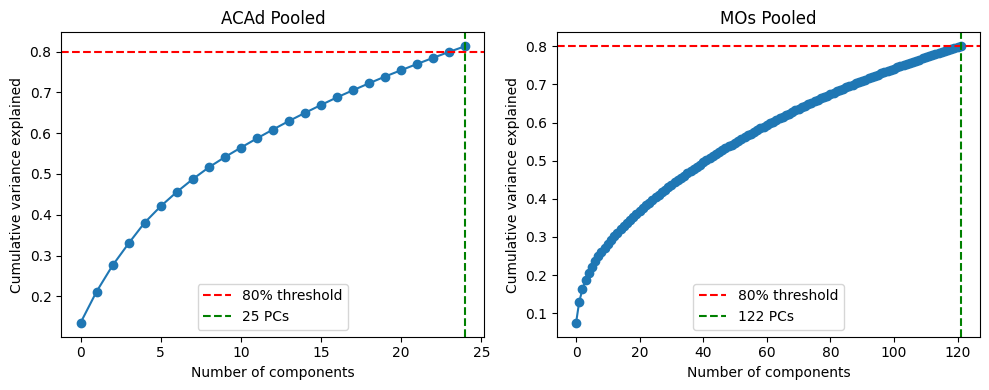

In [129]:
# Visualize variance explained (pooled PCA basis per area)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(A_cumvar[:A_npc], 'o-')
axes[0].axhline(0.8, color='r', linestyle='--', label='80% threshold')
axes[0].axvline(A_npc - 1, color='g', linestyle='--', label=f'{A_npc} PCs')
axes[0].set_title(f'{struct1} Pooled')
axes[0].set_xlabel('Number of components')
axes[0].set_ylabel('Cumulative variance explained')
axes[0].legend()

axes[1].plot(B_cumvar[:B_npc], 'o-')
axes[1].axhline(0.8, color='r', linestyle='--', label='80% threshold')
axes[1].axvline(B_npc - 1, color='g', linestyle='--', label=f'{B_npc} PCs')
axes[1].set_title(f'{struct2} Pooled')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance explained')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Perform CCA Between Brain Areas

In [130]:
def run_cca(X1, X2, n_components=None):
    """Run CCA between two datasets."""
    d = min(X1.shape[1], X2.shape[1])
    if n_components is None:
        n_components = d
    n_components = min(n_components, d, X1.shape[0] - 1, X2.shape[0] - 1)
    if n_components < 1:
        raise ValueError("Not enough samples to fit CCA.")
    cca = CCA(n_components=n_components)
    cca.fit(X1, X2)
    X1_c, X2_c = cca.transform(X1, X2)
    return cca, X1_c, X2_c

print("CCA function defined")

CCA function defined


In [131]:
# Match dimensions between areas
A_task_pca_m, B_task_pca_m, d_task = match_dims(A_task_pca, B_task_pca)
A_spont_pca_m, B_spont_pca_m, d_spont = match_dims(A_spont_pca, B_spont_pca)

print(f"Matched dimensions - Task: {d_task}, Spontaneous: {d_spont}")

# Choose number of CCA components (e.g., 5 or all available)
k_task = min(10, d_task)
k_spont = min(10, d_spont)

print(f"CCA components - Task: {k_task}, Spontaneous: {k_spont}")

Matched dimensions - Task: 25, Spontaneous: 25
CCA components - Task: 10, Spontaneous: 10


In [132]:
# Run CCA for task and spontaneous epochs
cca_task, A_task_c, B_task_c = run_cca(A_task_pca_m, B_task_pca_m, n_components=k_task)
cca_spont, A_spont_c, B_spont_c = run_cca(A_spont_pca_m, B_spont_pca_m, n_components=k_spont)

print(f"CCA completed")
print(f"  Task canonical variables shape: {A_task_c.shape}")
print(f"  Spontaneous canonical variables shape: {A_spont_c.shape}")

CCA completed
  Task canonical variables shape: (538, 10)
  Spontaneous canonical variables shape: (91, 10)


## 6. Calculate Canonical Correlations

In [133]:
# Calculate canonical correlations
corrs_task = canonical_corrs(A_task_c, B_task_c)
corrs_spont = canonical_corrs(A_spont_c, B_spont_c)

print(f"\nCanonical correlations:")
print(f"  Task: {corrs_task}")
print(f"  Spontaneous: {corrs_spont}")

# Basic comparison
print(f"\nMean correlation:")
print(f"  Task: {np.mean(corrs_task):.3f}")
print(f"  Spontaneous: {np.mean(corrs_spont):.3f}")
print(f"  Difference: {np.mean(corrs_task) - np.mean(corrs_spont):.3f}")


Canonical correlations:
  Task: [0.9202608  0.88580211 0.83343797 0.76512413 0.6882951  0.61073526
 0.58790475 0.49494746 0.47193665 0.41753425]
  Spontaneous: [0.95656277 0.93488786 0.9045471  0.88047504 0.82397331 0.79120925
 0.78336926 0.77112993 0.75396967 0.71120753]

Mean correlation:
  Task: 0.668
  Spontaneous: 0.831
  Difference: -0.164


In [134]:
# transform task data into spontaneous CCA space
A_task_c_in_spont, B_task_c_in_spont = cca_spont.transform(A_task_pca_m,B_task_pca_m)
corrs_task_in_spont = canonical_corrs(A_task_c_in_spont, B_task_c_in_spont)

print(f"\nCanonical correlations for task data projected into spontaneous CCA space:")
print(f"  Task in Spont CCA space: {corrs_task_in_spont}")


#transform spontaneous data into task CCA space
A_spont_c_in_task, B_spont_c_in_task = cca_task.transform(A_spont_pca_m, B_spont_pca_m)
corrs_spont_in_task = canonical_corrs(A_spont_c_in_task, B_spont_c_in_task)

print(f"\nCanonical correlations for spontaneous data projected into task CCA space:")
print(f"  Spont in Task CCA space: {corrs_spont_in_task}")

# mean correlations:
print(f"\nMean correlations in cross-projected spaces:")
print(f"  Task in Spont CCA space: {np.mean(corrs_task_in_spont):.3f}")
print(f"  Spont in Task CCA space: {np.mean(corrs_spont_in_task):.3f}")


Canonical correlations for task data projected into spontaneous CCA space:
  Task in Spont CCA space: [ 0.31584482 -0.07772128  0.46090184  0.25755053  0.25449561  0.07389737
  0.40476696  0.16801413  0.06256671  0.02938926]

Canonical correlations for spontaneous data projected into task CCA space:
  Spont in Task CCA space: [ 0.65024581  0.69579673  0.40441326  0.30363521  0.44654921  0.23238325
  0.33399092 -0.12992257  0.02734828  0.30350182]

Mean correlations in cross-projected spaces:
  Task in Spont CCA space: 0.195
  Spont in Task CCA space: 0.327


## 7. Bootstrap Significance Testing

In [117]:
def bootstrap_corrs(X, Y, n_components, n_boot=1000):
    """Bootstrap canonical correlations within an epoch."""
    n_samples = X.shape[0]
    boot_corrs = np.zeros((n_boot, n_components))
    for b in range(n_boot):
        idx = np.random.choice(n_samples, n_samples, replace=True)
        cca, X_c, Y_c = run_cca(X[idx], Y[idx], n_components=n_components)
        boot_corrs[b] = canonical_corrs(X_c, Y_c)
    return boot_corrs

print("Bootstrap function defined")

Bootstrap function defined


In [118]:
# Run bootstrap for task and spontaneous (reduced iterations for speed)
n_boot = 500
print(f"Running bootstrap with {n_boot} iterations...")

boot_task = bootstrap_corrs(A_task_pca_m, B_task_pca_m, k_task, n_boot=n_boot)
boot_spont = bootstrap_corrs(A_spont_pca_m, B_spont_pca_m, k_spont, n_boot=n_boot)

# Calculate confidence intervals
task_ci = np.percentile(boot_task, [2.5, 97.5], axis=0)
spont_ci = np.percentile(boot_spont, [2.5, 97.5], axis=0)

print(f"\nBootstrap completed")
print(f"Task 95% CI for component 1: [{task_ci[0, 0]:.3f}, {task_ci[1, 0]:.3f}]")
print(f"Spontaneous 95% CI for component 1: [{spont_ci[0, 0]:.3f}, {spont_ci[1, 0]:.3f}]")

Running bootstrap with 500 iterations...


KeyboardInterrupt: 

In [ ]:
# Test for significant difference between task and spontaneous
def bootstrap_diff(X1_task, Y1_task, X1_spont, Y1_spont, n_components, n_boot=1000):
    """Bootstrap the difference in canonical correlations between epochs."""
    n_task = X1_task.shape[0]
    n_spont = X1_spont.shape[0]
    diff_boot = np.zeros((n_boot, n_components))
    
    for b in range(n_boot):
        idx_task = np.random.choice(n_task, n_task, replace=True)
        idx_spont = np.random.choice(n_spont, n_spont, replace=True)
        
        _, X_task_c, Y_task_c = run_cca(X1_task[idx_task], Y1_task[idx_task], n_components)
        _, X_spont_c, Y_spont_c = run_cca(X1_spont[idx_spont], Y1_spont[idx_spont], n_components)
        
        r_task = canonical_corrs(X_task_c, Y_task_c)
        r_spont = canonical_corrs(X_spont_c, Y_spont_c)
        
        diff_boot[b] = r_task - r_spont
    
    return diff_boot

print("Bootstrap difference function defined")

Bootstrap difference function defined


In [72]:
# Run bootstrap for differences
k_min = min(k_task, k_spont)
print(f"Running bootstrap for differences with {n_boot} iterations...")

diff_boot = bootstrap_diff(
    A_task_pca_m, B_task_pca_m,
    A_spont_pca_m, B_spont_pca_m,
    n_components=k_min,
    n_boot=n_boot
)

diff_ci = np.percentile(diff_boot, [2.5, 97.5], axis=0)
diff_mean = np.mean(diff_boot, axis=0)

print(f"\nDifference in canonical correlations (Task - Spontaneous):")
for i in range(k_min):
    significant = "***" if (diff_ci[0, i] > 0 or diff_ci[1, i] < 0) else "n.s."
    print(f"  Component {i+1}: {diff_mean[i]:.3f} [{diff_ci[0, i]:.3f}, {diff_ci[1, i]:.3f}] {significant}")

Running bootstrap for differences with 500 iterations...


c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
c:\Anaconda3\envs\dr_ibl_analysis\Lib\site-packages\sklearn\cross_decomposition\_pls.py:113: Con


Difference in canonical correlations (Task - Spontaneous):
  Component 1: -0.089 [-0.123, -0.052] ***
  Component 2: -0.156 [-0.195, -0.113] ***
  Component 3: -0.164 [-0.204, -0.126] ***
  Component 4: -0.168 [-0.208, -0.132] ***
  Component 5: -0.170 [-0.213, -0.133] ***
  Component 6: -0.172 [-0.214, -0.132] ***
  Component 7: -0.173 [-0.214, -0.133] ***
  Component 8: -0.176 [-0.215, -0.135] ***
  Component 9: -0.176 [-0.212, -0.138] ***
  Component 10: -0.176 [-0.219, -0.137] ***


## 8. Compare Communication Subspaces Across Epochs

In [135]:
def principal_angles(U, V):
    """
    Calculate principal angles between two subspaces.
    U, V: (d × k) matrices.
    Returns principal angles in radians.
    """
    Uo, _ = np.linalg.qr(U)
    Vo, _ = np.linalg.qr(V)
    s = np.linalg.svd(Uo.T @ Vo, compute_uv=False)
    s = np.clip(s, -1.0, 1.0)
    return np.arccos(s)

print("Principal angles function defined")

Principal angles function defined


In [136]:
# Compare subspaces for area A (struct1)
k = min(k_task, k_spont)
subspace_compare_mode = "pooled_pca"  # "pooled_pca" or "neuron_space"

if subspace_compare_mode == "pooled_pca":
    U_task_A = cca_task.x_weights_[:, :k]
    U_spont_A = cca_spont.x_weights_[:, :k]
    U_task_B = cca_task.y_weights_[:, :k]
    U_spont_B = cca_spont.y_weights_[:, :k]
elif subspace_compare_mode == "neuron_space":
    U_task_A = pca_A.components_.T @ cca_task.x_weights_[:, :k]
    U_spont_A = pca_A.components_.T @ cca_spont.x_weights_[:, :k]
    U_task_B = pca_B.components_.T @ cca_task.y_weights_[:, :k]
    U_spont_B = pca_B.components_.T @ cca_spont.y_weights_[:, :k]
else:
    raise ValueError("subspace_compare_mode must be 'pooled_pca' or 'neuron_space'.")

angles_A = principal_angles(U_task_A, U_spont_A)
angles_A_deg = angles_A * 180 / np.pi

print(f"\nPrincipal angles for {struct1} (degrees):")
print(angles_A_deg)
print(f"Mean angle: {np.mean(angles_A_deg):.2f}°")

angles_B = principal_angles(U_task_B, U_spont_B)
angles_B_deg = angles_B * 180 / np.pi

print(f"\nPrincipal angles for {struct2} (degrees):")
print(angles_B_deg)
print(f"Mean angle: {np.mean(angles_B_deg):.2f}°")


Principal angles for ACAd (degrees):
[10.12929247 20.36005235 35.17828498 38.31183553 40.17291185 52.52144107
 59.6453343  68.55680886 75.12948075 87.28612716]
Mean angle: 48.73°

Principal angles for MOs (degrees):
[ 8.81213357 18.95045218 22.85287794 31.65049831 41.16112914 43.63804597
 62.88855895 68.90272287 80.8168978  86.52219464]
Mean angle: 46.62°


## 9. Visualize Canonical Correlations

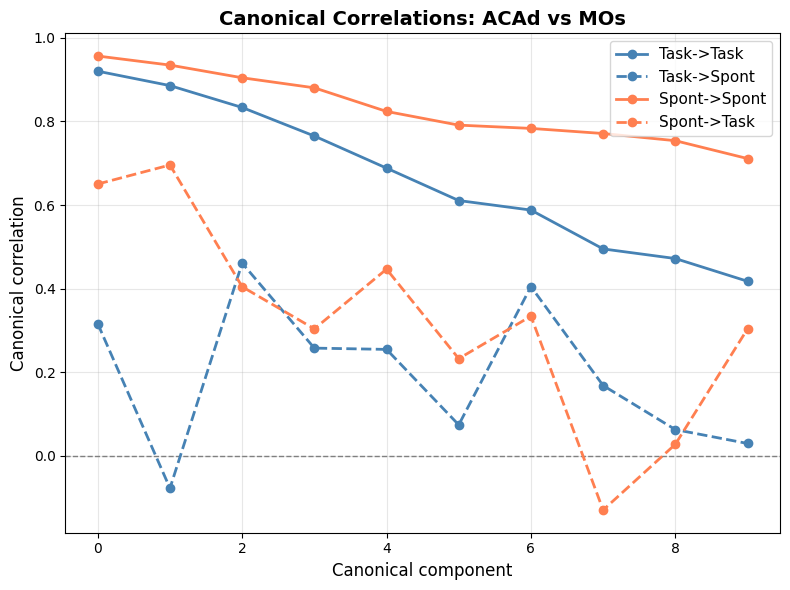

In [137]:
# Plot canonical correlations with bootstrap confidence intervals
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

x_task = np.arange(len(corrs_task))
x_spont = np.arange(len(corrs_spont))

ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# Plot task
ax.errorbar(
    x_task, corrs_task,
    # yerr=np.abs([task_ci[0]-corrs_task, task_ci[1]-corrs_task]),
    fmt='o-', linewidth=2, capsize=5, capthick=2,
    label='Task->Task', color='steelblue'
)

ax.errorbar(
    x_task, corrs_task_in_spont,
    # yerr=np.abs([task_ci[0]-corrs_task_in_spont, task_ci[1]-corrs_task_in_spont]),
    fmt='o--', linewidth=2, capsize=5, capthick=2,
    label='Task->Spont', color='steelblue'
)

# Plot spontaneous
ax.errorbar(
    x_spont, corrs_spont,
    # yerr=[spont_ci[0]-corrs_spont, spont_ci[1]-corrs_spont],
    fmt='o-', linewidth=2, capsize=5, capthick=2,
    label='Spont->Spont', color='coral'
)

ax.errorbar(
    x_spont, corrs_spont_in_task,
    # yerr=[spont_ci[0]-corrs_spont_in_task, spont_ci[1]-corrs_spont_in_task],
    fmt='o--', linewidth=2, capsize=5, capthick=2,
    label='Spont->Task', color='coral'
)

ax.set_xlabel('Canonical component', fontsize=12)
ax.set_ylabel('Canonical correlation', fontsize=12)
ax.set_title(f'Canonical Correlations: {struct1} vs {struct2}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
# ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [138]:
# [task_ci[0]-corrs_task, task_ci[1]-corrs_task]

NameError: name 'boot_task' is not defined

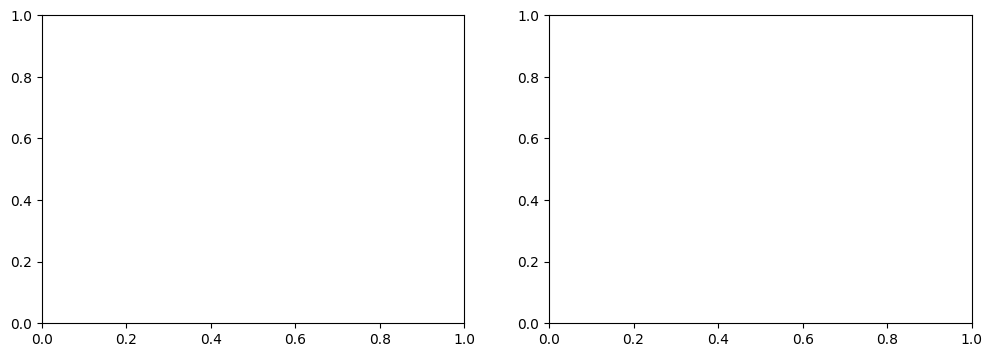

In [139]:
# Plot bootstrap distributions for first canonical component
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(boot_task[:, 0], bins=30, alpha=0.7, color='steelblue', label='Task')
axes[0].hist(boot_spont[:, 0], bins=30, alpha=0.7, color='coral', label='Spontaneous')
axes[0].axvline(corrs_task[0], color='steelblue', linestyle='--', linewidth=2, label='Task observed')
axes[0].axvline(corrs_spont[0], color='coral', linestyle='--', linewidth=2, label='Spont observed')
axes[0].set_xlabel('Canonical correlation', fontsize=11)
axes[0].set_ylabel('Bootstrap count', fontsize=11)
axes[0].set_title('Bootstrap Distribution: Component 1', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Plot difference distribution
axes[1].hist(diff_boot[:, 0], bins=30, alpha=0.7, color='purple')
axes[1].axvline(0, color='black', linestyle='--', linewidth=2, label='No difference')
axes[1].axvline(diff_mean[0], color='red', linestyle='--', linewidth=2, label='Observed difference')
axes[1].axvline(diff_ci[0, 0], color='red', linestyle=':', linewidth=1.5, label='95% CI')
axes[1].axvline(diff_ci[1, 0], color='red', linestyle=':', linewidth=1.5)
axes[1].set_xlabel('Difference (Task - Spontaneous)', fontsize=11)
axes[1].set_ylabel('Bootstrap count', fontsize=11)
axes[1].set_title('Bootstrap Difference: Component 1', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## 10. Visualize Subspace Angles

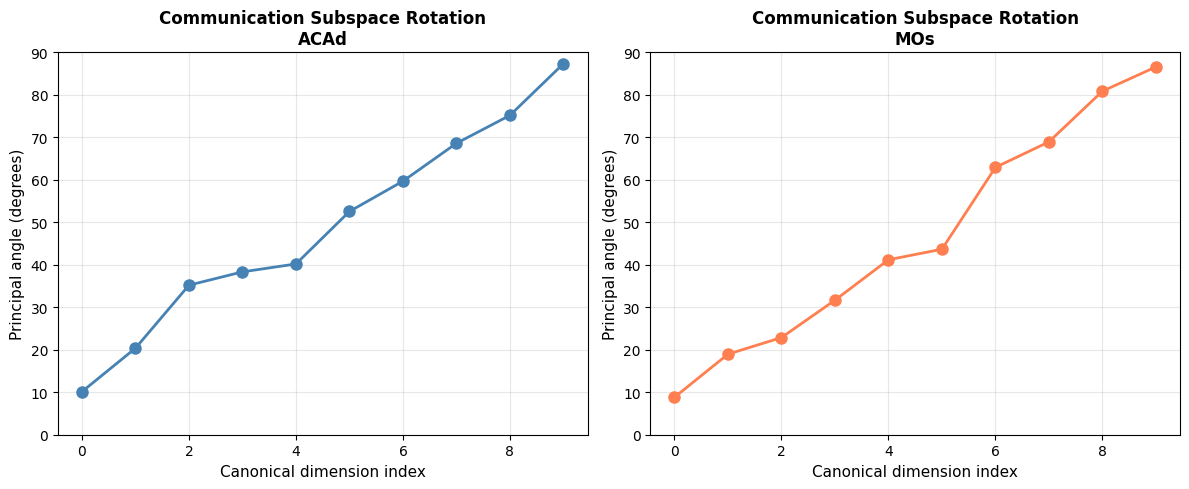


Interpretation:
  Small angles (< 30°): Subspaces are very similar between task and spontaneous
  Medium angles (30-60°): Moderate rotation of subspaces
  Large angles (> 60°): Substantial reorganization of communication subspace


In [140]:
# Plot principal angles
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(angles_A_deg, 'o-', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Canonical dimension index', fontsize=11)
axes[0].set_ylabel('Principal angle (degrees)', fontsize=11)
axes[0].set_title(f'Communication Subspace Rotation\n{struct1}', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0, 90])

axes[1].plot(angles_B_deg, 'o-', linewidth=2, markersize=8, color='coral')
axes[1].set_xlabel('Canonical dimension index', fontsize=11)
axes[1].set_ylabel('Principal angle (degrees)', fontsize=11)
axes[1].set_title(f'Communication Subspace Rotation\n{struct2}', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 90])

plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"  Small angles (< 30°): Subspaces are very similar between task and spontaneous")
print(f"  Medium angles (30-60°): Moderate rotation of subspaces")
print(f"  Large angles (> 60°): Substantial reorganization of communication subspace")

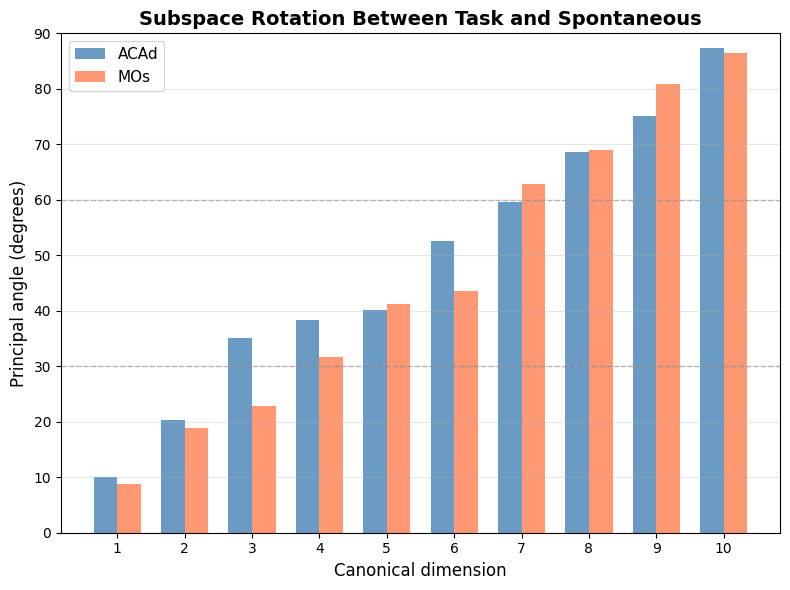

In [141]:
# Combined visualization of angles
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

x = np.arange(len(angles_A_deg))
width = 0.35

bars1 = ax.bar(x - width/2, angles_A_deg, width, label=struct1, color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, angles_B_deg, width, label=struct2, color='coral', alpha=0.8)

ax.set_xlabel('Canonical dimension', fontsize=12)
ax.set_ylabel('Principal angle (degrees)', fontsize=12)
ax.set_title('Subspace Rotation Between Task and Spontaneous', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{i+1}' for i in x])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 90])

# Add reference lines
ax.axhline(30, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(60, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

## 11. Plot Canonical Variable Trajectories

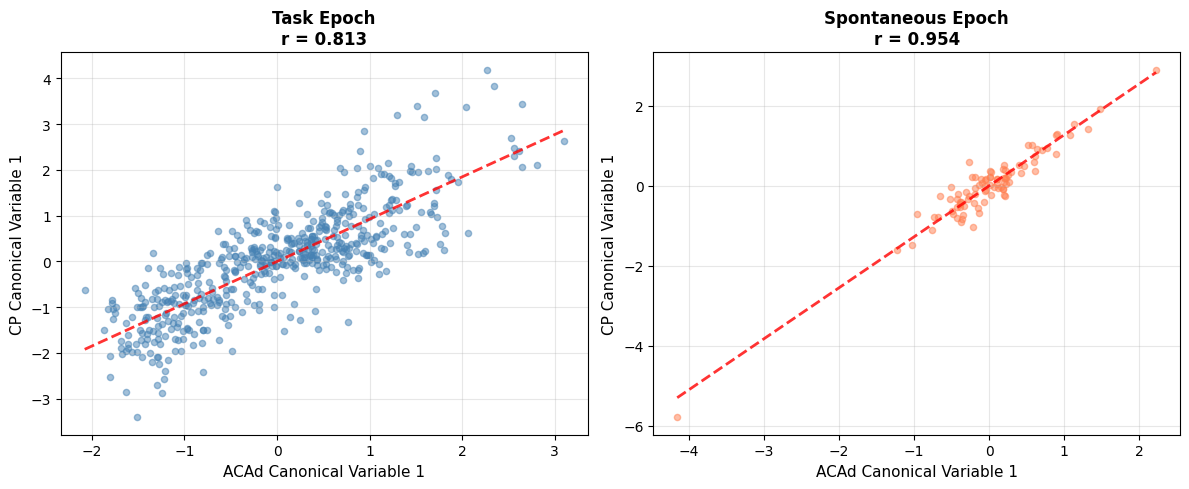

In [104]:
# Plot relationship between canonical variables for first component
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Task
axes[0].scatter(A_task_c[:, 0], B_task_c[:, 0], alpha=0.5, s=20, color='steelblue')
axes[0].set_xlabel(f'{struct1} Canonical Variable 1', fontsize=11)
axes[0].set_ylabel(f'{struct2} Canonical Variable 1', fontsize=11)
axes[0].set_title(f'Task Epoch\nr = {corrs_task[0]:.3f}', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Add regression line
z = np.polyfit(A_task_c[:, 0], B_task_c[:, 0], 1)
p = np.poly1d(z)
x_line = np.linspace(A_task_c[:, 0].min(), A_task_c[:, 0].max(), 100)
axes[0].plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8)

# Spontaneous
axes[1].scatter(A_spont_c[:, 0], B_spont_c[:, 0], alpha=0.5, s=20, color='coral')
axes[1].set_xlabel(f'{struct1} Canonical Variable 1', fontsize=11)
axes[1].set_ylabel(f'{struct2} Canonical Variable 1', fontsize=11)
axes[1].set_title(f'Spontaneous Epoch\nr = {corrs_spont[0]:.3f}', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

# Add regression line
z = np.polyfit(A_spont_c[:, 0], B_spont_c[:, 0], 1)
p = np.poly1d(z)
x_line = np.linspace(A_spont_c[:, 0].min(), A_spont_c[:, 0].max(), 100)
axes[1].plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()

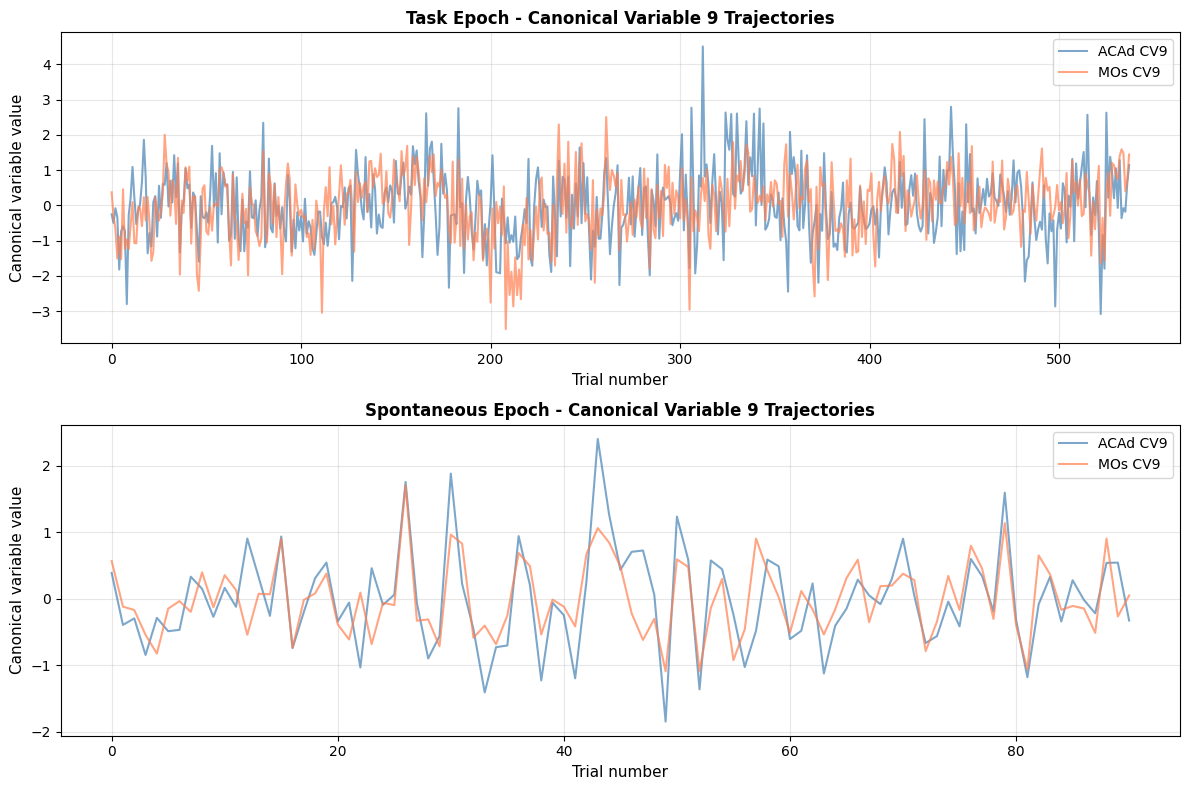

In [142]:
# Plot time series of canonical variables (first component)
plot_component=9

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Task
axes[0].plot(A_task_c[:, plot_component], label=f'{struct1} CV{plot_component}', linewidth=1.5, alpha=0.7, color='steelblue')
axes[0].plot(B_task_c[:, plot_component], label=f'{struct2} CV{plot_component}', linewidth=1.5, alpha=0.7, color='coral')
axes[0].set_xlabel('Trial number', fontsize=11)
axes[0].set_ylabel('Canonical variable value', fontsize=11)
axes[0].set_title(f'Task Epoch - Canonical Variable {plot_component} Trajectories', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Spontaneous
axes[1].plot(A_spont_c[:, plot_component], label=f'{struct1} CV{plot_component}', linewidth=1.5, alpha=0.7, color='steelblue')
axes[1].plot(B_spont_c[:, plot_component], label=f'{struct2} CV{plot_component}', linewidth=1.5, alpha=0.7, color='coral')
axes[1].set_xlabel('Trial number', fontsize=11)
axes[1].set_ylabel('Canonical variable value', fontsize=11)
axes[1].set_title(f'Spontaneous Epoch - Canonical Variable {plot_component} Trajectories', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This analysis applies CCA to assess neural coupling between brain areas across task and spontaneous epochs:

1. **PCA preprocessing**: Reduced dimensionality while retaining 80% variance for each area/epoch
2. **CCA**: Identified maximally correlated dimensions between paired brain areas
3. **Bootstrap testing**: Quantified statistical significance of correlations and differences
4. **Subspace comparison**: Measured rotation of communication subspaces via principal angles
5. **Visualization**: Comprehensive plots showing correlation strength, confidence intervals, and trajectories

**Key findings:**
- Canonical correlations quantify trial-by-trial coupling between areas
- Bootstrap CI indicates reliability of estimated correlations
- Principal angles reveal whether the neural subspace mediating communication changes between epochs
- Small angles suggest persistent communication structure; large angles indicate reorganization

In [ ]:
# Optional: Save results for further analysis
results = {
    'structures': [struct1, struct2],
    'canonical_correlations': {
        'task': corrs_task,
        'spontaneous': corrs_spont,
        'difference': corrs_task[:k_min] - corrs_spont[:k_min]
    },
    'bootstrap': {
        'task_ci': task_ci,
        'spont_ci': spont_ci,
        'diff_ci': diff_ci,
        'diff_mean': diff_mean
    },
    'principal_angles': {
        struct1: angles_A_deg,
        struct2: angles_B_deg
    },
    'n_components': {
        'task': k_task,
        'spontaneous': k_spont
    }
}

print("\nAnalysis complete! Results dictionary contains:")
for key in results.keys():
    print(f"  - {key}")